In [1]:
# @title Prepare Environment

# Установки для VBench

!pip install -q decord openai-clip timm fvcore iopath yacs fairscale pyiqa imageio-ffmpeg
!test -d /content/VBench || git clone https://github.com/Vchitect/VBench.git

# Установки для FVD
!pip install scipy pandas opencv-python imageio-ffmpeg
!git clone https://github.com/piergiaj/pytorch-i3d.git

#Установки для основного пайплайна
!pip install torch==2.6
!pip install torchvision==0.21

!pip install torchsde einops diffusers accelerate
!pip install -q av gguf triton sageattention
!pip install gguf
!pip install av

!git clone https://github.com/Isi-dev/ComfyUI /content/ComfyUI || true
!git clone https://github.com/Isi-dev/ComfyUI_GGUF.git /content/ComfyUI/custom_nodes/ComfyUI_GGUF || true

!pip install -r /content/ComfyUI/custom_nodes/ComfyUI_GGUF/requirements.txt
!apt -y install -qq aria2 ffmpeg

!mkdir -p /content/ComfyUI/models/unet
!mkdir -p /content/ComfyUI/models/text_encoders
!mkdir -p /content/ComfyUI/models/vae
!mkdir -p /content/ComfyUI/models/clip_vision
!mkdir -p /content/ComfyUI/input
!mkdir -p /content/ComfyUI/output

useQ6 = False  # @param {"type":"boolean"}

if useQ6:
    !aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
      "https://huggingface.co/befox/WAN2.2-14B-Rapid-AllInOne-GGUF/resolve/main/v10/wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf?download=true" \
      -d /content/ComfyUI/models/unet \
      -o wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf
    unet_name = "wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf"
else:
    # если у тебя нет подтверждённой ссылки на Q8, лучше не притворяться что качаешь Q8
    !aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
      "https://huggingface.co/befox/WAN2.2-14B-Rapid-AllInOne-GGUF/resolve/main/v10/wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf?download=true" \
      -d /content/ComfyUI/models/unet \
      -o wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf
    unet_name = "wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf"

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
  "https://huggingface.co/NSFW-API/NSFW-Wan-UMT5-XXL/resolve/main/nsfw_wan_umt5-xxl_fp8_scaled.safetensors?download=true" \
  -d /content/ComfyUI/models/text_encoders \
  -o umt5_xxl_fp8_e4m3fn_scaled.safetensors

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
  "https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/vae/wan_2.1_vae.safetensors" \
  -d /content/ComfyUI/models/vae \
  -o wan_2.1_vae.safetensors

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
  "https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/clip_vision/clip_vision_h.safetensors" \
  -d /content/ComfyUI/models/clip_vision \
  -o clip_vision_h.safetensors

print("✅ Environment prepared")
print("UNet:", unet_name)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 17.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 20.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [3]:
import os
import sys
import json
import shutil
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import cv2
import imageio
import matplotlib.pyplot as plt

from PIL import Image
from scipy import linalg
from IPython.display import display, HTML, Image as IPImage

# Если запускается в Colab
try:
    from google.colab import files
except ImportError:
    files = None

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("PYTORCH_CUDA_ALLOC_CONF set to expandable_segments:True")

# Пути должны быть добавлены ДО импортов ComfyUI
COMFY_ROOT = Path("/content/ComfyUI")

if not COMFY_ROOT.exists():
    raise FileNotFoundError(f"ComfyUI not found: {COMFY_ROOT}")


if str(COMFY_ROOT) not in sys.path:
    sys.path.insert(0, str(COMFY_ROOT))


# Импорты ComfyUI
from comfy_extras.nodes_wan import WanImageToVideo
from comfy_extras.nodes_model_advanced import ModelSamplingSD3
from custom_nodes.ComfyUI_GGUF.nodes import UnetLoaderGGUF
from nodes import (
    CLIPLoader,
    CLIPTextEncode,
    VAEDecode,
    VAELoader,
    KSampler,
    LoadImage,
    CLIPVisionLoader,
    CLIPVisionEncode,
)
from comfy import model_management



PYTORCH_CUDA_ALLOC_CONF set to expandable_segments:True


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# World Metadata


## World Spec

In [5]:
# ===== Extended world_spec block =====

from copy import deepcopy
from pathlib import Path


DEFAULT_CAMERA_PROMPTS = [
    "static camera",
    "slow zoom in",
    "pan left",
    "slight forward motion",
]


def build_world_spec(
    image_path: str,
    next_scene_prompt: str,
    camera_prompt: str = "static camera",
    target_objects=None,
    main_subject: str = None,
    secondary_subjects=None,
    expected_action: str = None,
    scene_context: str = None,
    style_tags=None,
    consistency_constraints=None,
    chunk_idx: int = 0,
    previous_chunk_last_frame: str = None,
    model_name: str = "custom_i2v_model",
    model_type: str = "videogen",
    generate_type: str = "i2v",
    frames_per_chunk: int = 40,
    fps: int = 8,
    resolution=(320, 512),
    num_chunks: int = 3,
    camera_trajectory_gt=None,
    camera_transform_hint=None,
    motion_mask_hint=None,
    expected_scene_transition: str = None,
    chunk_prompt_schedule=None,
    entity_region_hints=None,
    affected_entities=None,
    unaffected_entities=None,
    expected_motion=None,
    event_sequence=None,
    revisit_pairs=None,
):
    if target_objects is None:
        target_objects = []
    if secondary_subjects is None:
        secondary_subjects = []
    if style_tags is None:
        style_tags = []
    if consistency_constraints is None:
        consistency_constraints = [
            "keep the same subject identity",
            "keep the same scene",
            "avoid sudden scene changes",
            "avoid extra objects",
        ]
    if chunk_prompt_schedule is None:
        chunk_prompt_schedule = {}
    if entity_region_hints is None:
        entity_region_hints = {}

    resolution = list(resolution)

    layout_spec = {
        "camera_prompt": camera_prompt,
        "camera_instruction_text": camera_prompt,
        "camera_trajectory_gt": camera_trajectory_gt,
        "camera_transform_hint": camera_transform_hint,
    }

    world_spec = {
        # ---------- rollout bookkeeping ----------
        "chunk_idx": chunk_idx,
        "num_chunks": num_chunks,
        "current_scene_image": str(image_path),
        "previous_chunk_last_frame": previous_chunk_last_frame,

        # ---------- model metadata ----------
        "model_name": model_name,
        "model_type": model_type,
        "generate_type": generate_type,

        # ---------- generation config ----------
        "frames_per_chunk": frames_per_chunk,
        "fps": fps,
        "resolution": resolution,

        # ---------- semantic specification ----------
        "next_scene_prompt": next_scene_prompt,
        "expected_scene_transition": expected_scene_transition,
        "camera_prompt": camera_prompt,
        "camera_instruction_text": camera_prompt,
        "layout_spec": layout_spec,
        "camera_trajectory_gt": camera_trajectory_gt,
        "camera_transform_hint": camera_transform_hint,
        "motion_mask_hint": motion_mask_hint,
        "entity_region_hints": deepcopy(entity_region_hints),

        "main_subject": main_subject,
        "secondary_subjects": secondary_subjects,
        "target_objects": target_objects,
        "expected_action": expected_action,
        "scene_context": scene_context,
        "style_tags": style_tags,
        "consistency_constraints": consistency_constraints,
        "chunk_prompt_schedule": chunk_prompt_schedule,
        "affected_entities": deepcopy(affected_entities),
        "unaffected_entities": deepcopy(unaffected_entities),
        "expected_motion": deepcopy(expected_motion),
        "event_sequence": deepcopy(event_sequence),
        "revisit_pairs": deepcopy(revisit_pairs),
    }

    return world_spec


## Сборка positive_prompt из world_spec

In [6]:
# ===== Build positive prompt from extended world_spec =====

def _list_to_text(values):
    if not values:
        return ""
    if len(values) == 1:
        return values[0]
    return ", ".join(values[:-1]) + f" and {values[-1]}"


def _get_chunk_prompt(world_spec: dict):
    chunk_idx = world_spec.get("chunk_idx", 0)
    schedule = world_spec.get("chunk_prompt_schedule", {}) or {}
    if chunk_idx in schedule:
        return schedule[chunk_idx]
    return world_spec.get("next_scene_prompt", "")


def build_world_prompt(world_spec: dict):
    parts = []

    base_prompt = _get_chunk_prompt(world_spec)
    if base_prompt:
        parts.append(base_prompt.strip().rstrip("."))

    if world_spec.get("scene_context"):
        parts.append(f"scene context: {world_spec['scene_context']}")

    if world_spec.get("main_subject"):
        parts.append(f"main subject: {world_spec['main_subject']}")

    secondary = world_spec.get("secondary_subjects", [])
    if secondary:
        parts.append(f"secondary subjects: {_list_to_text(secondary)}")

    target_objects = world_spec.get("target_objects", [])
    if target_objects:
        parts.append(
            f"target objects visible in scene: {_list_to_text(target_objects)}")

    if world_spec.get("expected_action"):
        parts.append(f"expected action: {world_spec['expected_action']}")

    if world_spec.get("expected_scene_transition"):
        parts.append(
            f"expected scene transition: {world_spec['expected_scene_transition']}")

    style_tags = world_spec.get("style_tags", [])
    if style_tags:
        parts.append(f"style: {_list_to_text(style_tags)}")

    if world_spec.get("camera_instruction_text"):
        parts.append(f"camera: {world_spec['camera_instruction_text']}")

    constraints = world_spec.get("consistency_constraints", [])
    if constraints:
        parts.append("constraints: " + "; ".join(constraints))

    final_prompt = ". ".join(parts).strip()
    if not final_prompt.endswith("."):
        final_prompt += "."
    return final_prompt

## Обновление world_spec после каждого чанка

In [8]:
# ===== Update extended world_spec after each chunk =====

def update_world_spec_after_chunk(
    world_spec: dict,
    last_frame_path: str,
    chunk_idx: int,
):
    new_spec = deepcopy(world_spec)
    new_spec["chunk_idx"] = chunk_idx
    new_spec["previous_chunk_last_frame"] = world_spec.get("current_scene_image")
    new_spec["current_scene_image"] = str(last_frame_path)
    return new_spec


# ===== Debug preview =====

def preview_world_spec(world_spec: dict):
    preview_keys = [
        "chunk_idx",
        "num_chunks",
        "model_name",
        "model_type",
        "generate_type",
        "current_scene_image",
        "previous_chunk_last_frame",
        "next_scene_prompt",
        "camera_prompt",
        "camera_instruction_text",
        "main_subject",
        "secondary_subjects",
        "target_objects",
        "expected_action",
        "scene_context",
        "style_tags",
        "frames_per_chunk",
        "fps",
        "resolution",
        "layout_spec",
        "motion_mask_hint",
        "camera_trajectory_gt",
        "camera_transform_hint",
        "event_sequence",
        "revisit_pairs",
    ]
    return {k: world_spec.get(k) for k in preview_keys}


# Omni-Metric

Core Omni metric implementations now live in `src/metrics/omni/`.
The notebook keeps only lightweight orchestration, logging helpers, and the optional CLIP-vision embedding backend passed into the modular runner.


In [9]:
# ===== Omni notebook-side imports =====

from src.metrics.omni.common.results import (
    OMNI_CLIP_LOG_COLUMNS,
    OMNI_IMPLEMENTATION_STATUS,
    OMNI_SCORE_KEYS,
    OMNI_VISUAL_STACK_KEYS,
    omni_jsonable as _omni_jsonable,
)
from src.metrics.omni.summary import add_optional_full_rollout_omni_summary

# Core Omni helpers now live in src/metrics/omni/.
# Notebook keeps only orchestration, config, logging, and visualization.


# VBench

В проекте VBench используется для оценки качества каждого сгенерированного чанка и полного итогового rollout-видео.

Мы считаем 6 метрик:

- **Subject Consistency** — насколько стабильно главный объект сохраняет внешний вид внутри чанка
- **Background Consistency** — насколько стабильно сохраняется фон и сцена
- **Motion Smoothness** — насколько плавным и естественным выглядит движение
- **Dynamic Degree** — насколько в видео вообще присутствует заметная динамика
- **Aesthetic Quality** — общая визуальная привлекательность кадров
- **Imaging Quality** — техническое качество изображения: резкость, шум, артефакты, пересветы

Метрики считаются:
- после генерации каждого чанка
- сохраняются вместе с `chunk_idx` в историю и CSV
- затем используются для построения графиков по номеру чанка
- дополнительно считаются для полного rollout-видео

Это позволяет отслеживать, ухудшается ли качество генерации от чанка к чанку и как ведет себя итоговое длинное видео.


In [10]:
from src.metrics.vbench import DEFAULT_VBENCH_DIMENSIONS, VBenchMetric, summarize_chunk_vbench_metrics

VBENCH_CUSTOM_DIMS = list(DEFAULT_VBENCH_DIMENSIONS)


def save_chunk_metrics_csv(
    clip_log,
    out_csv_path: str,
):
    out_csv_path = Path(out_csv_path)
    out_csv_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(clip_log)
    df.to_csv(out_csv_path, index=False)
    return str(out_csv_path), df


def save_rollout_metrics_csv(
    rollout_record: dict,
    out_csv_path: str,
):
    out_csv_path = Path(out_csv_path)
    out_csv_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame([rollout_record])
    df.to_csv(out_csv_path, index=False)
    return str(out_csv_path), df


# FVD

## FVD через `src/metrics/fvd`


In [13]:
from src.metrics.fvd import FVDMetric

fvd_metric = FVDMetric(
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=4,
    num_frames=16,
    resize_to=(224, 224),
    sampling_strategy="uniform",
    max_pairs=None,
    cache_features=False,
    cache_dir=None,
    verbose=True,
)


# Основной пайплайн

In [16]:


from src.metrics.omni import CameraControlMetric, InterCovMetric, InterOrderMetric, InterStabLMetric, InterStabNMetric, ObjectControlMetric, OmniMetricRunner, TransitionsDetectMetric, build_omni_spec as modular_build_omni_spec, configure_omni_clip_backend, frame_embedding

# ---------- init lightweight node wrappers ----------
unet_loader = UnetLoaderGGUF()
model_sampling = ModelSamplingSD3()
clip_loader = CLIPLoader()
clip_encode_positive = CLIPTextEncode()
clip_encode_negative = CLIPTextEncode()
vae_loader = VAELoader()
clip_vision_loader = CLIPVisionLoader()
clip_vision_encode = CLIPVisionEncode()
configure_omni_clip_backend(
    loader=clip_vision_loader,
    encoder=clip_vision_encode,
    reset_model_cache=True,
)
load_image = LoadImage()
wan_image_to_video = WanImageToVideo()
ksampler = KSampler()
vae_decode = VAEDecode()


# ---------- memory ----------
def clear_memory(aggressive: bool = True):
    gc.collect()

    try:
        if aggressive:
            model_management.unload_all_models()
        if hasattr(model_management, "cleanup_models_gc"):
            model_management.cleanup_models_gc()
        else:
            model_management.cleanup_models()
    except Exception:
        pass

    try:
        model_management.soft_empty_cache()
    except Exception:
        pass

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

    gc.collect()


omni_runner = OmniMetricRunner(
    interstab_l_metric=InterStabLMetric(
        embedding_backend=frame_embedding,
        static_threshold=0.08,
        fallback_pair_strategy="long_range",
        verbose=False,
    ),
    interstab_n_metric=InterStabNMetric(
        flow_backend=None,
        beta=1.25,
        region_padding=0.0,
        verbose=False,
    ),
    intercov_metric=InterCovMetric(
        flow_backend=None,
        semantic_verifier=None,
        appearance_weight=1.0,
        motion_weight=1.0,
        position_weight=1.0,
        verbose=False,
        embedding_backend=frame_embedding,
    ),
    interorder_metric=InterOrderMetric(
        event_verifier=None,
        embedding_backend=frame_embedding,
        verbose=False,
        flow_backend=None,
    ),
    transitions_detect_metric=TransitionsDetectMetric(
        threshold=None,
        min_scene_length=1,
        smoothing_window=None,
        verbose=False,
    ),
    object_control_metric=ObjectControlMetric(
        object_verifier=None,
        embedding_backend=frame_embedding,
        verbose=False,
    ),
    camera_control_metric=CameraControlMetric(
        camera_verifier=None,
        flow_backend=None,
        verbose=False,
    ),
    verbose=False,
)


# ---------- io ----------
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def upload_image():
    ensure_dir("/content/ComfyUI/input")
    uploaded = files.upload()

    for filename in uploaded.keys():
        src_path = f"/content/{filename}"
        dest_path = f"/content/ComfyUI/input/{filename}"
        shutil.move(src_path, dest_path)
        print(f"✅ Image saved to: {dest_path}")
        return dest_path

    return None


def display_video(video_path: str, width: int = 512):
    from base64 import b64encode

    video_data = open(video_path, "rb").read()

    if video_path.lower().endswith(".mp4"):
        mime_type = "video/mp4"
    elif video_path.lower().endswith(".webm"):
        mime_type = "video/webm"
    else:
        mime_type = "video/mp4"

    data_url = f"data:{mime_type};base64," + b64encode(video_data).decode()

    display(HTML(f"""
    <video width="{width}" controls autoplay loop>
        <source src="{data_url}" type="{mime_type}">
    </video>
    """))


def save_as_mp4(images, filename_prefix, fps, output_dir="/content/ComfyUI/output"):
    ensure_dir(output_dir)
    output_path = f"{output_dir}/{filename_prefix}.mp4"
    frames = [(img.cpu().numpy() * 255).astype(np.uint8) for img in images]

    with imageio.get_writer(output_path, fps=fps) as writer:
        for frame in frames:
            writer.append_data(frame)

    return output_path


def save_as_webm(images, filename_prefix, fps, codec="vp9", quality=10, output_dir="/content/ComfyUI/output"):
    ensure_dir(output_dir)
    output_path = f"{output_dir}/{filename_prefix}.webm"
    frames = [(img.cpu().numpy() * 255).astype(np.uint8) for img in images]

    with imageio.get_writer(
        output_path,
        format="FFMPEG",
        mode="I",
        fps=int(fps),
        codec=str(codec),
        quality=int(quality),
        output_params=["-crf", str(int(quality))]
    ) as writer:
        for frame in frames:
            writer.append_data(frame)

    return output_path


def save_as_image(image, filename_prefix, output_dir="/content/ComfyUI/output"):
    ensure_dir(output_dir)
    output_path = f"{output_dir}/{filename_prefix}.png"
    frame = (image.cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(frame).save(output_path)
    return output_path


# ---------- clip similarity utils ----------
def _ensure_bhwc(img: torch.Tensor):
    return img.unsqueeze(0) if img.dim() == 3 else img


def _extract_vec(cv_out):
    if torch.is_tensor(cv_out):
        v = cv_out
    elif isinstance(cv_out, dict):
        if "image_embeds" in cv_out:
            v = cv_out["image_embeds"]
        elif "pooled_output" in cv_out:
            v = cv_out["pooled_output"]
        elif "last_hidden_state" in cv_out:
            t = cv_out["last_hidden_state"]
            v = t[:, 0] if t.ndim == 3 else t
        else:
            v = next((x for x in cv_out.values() if torch.is_tensor(x)), None)
            if v is None:
                raise ValueError(
                    f"Unknown CLIP vision output keys: {list(cv_out.keys())}")
    else:
        if hasattr(cv_out, "image_embeds"):
            v = getattr(cv_out, "image_embeds")
        elif hasattr(cv_out, "pooled_output"):
            v = getattr(cv_out, "pooled_output")
        elif hasattr(cv_out, "last_hidden_state"):
            t = getattr(cv_out, "last_hidden_state")
            v = t[:, 0] if t.ndim == 3 else t
        else:
            raise ValueError(
                f"Unknown CLIP vision output type: {type(cv_out)}")

    v = v.detach().float()
    if v.ndim > 2:
        v = v.flatten(start_dim=1)
    if v.ndim == 2 and v.shape[0] == 1:
        v = v[0]
    return v


def _cosine(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8):
    a = a.flatten()
    b = b.flatten()
    return float((a @ b) / (a.norm() * b.norm() + eps))


def plot_similarity(times, sims, title="CLIP similarity"):
    plt.figure(figsize=(10, 4))
    plt.plot(times, sims)
    plt.ylim(-0.1, 1.0)
    plt.xlabel("time (s)")
    plt.ylabel("cosine similarity")
    plt.title(title)
    plt.show()


def save_clip_log(clip_log, path="/content/ComfyUI/output/clip_similarity_log.json"):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(clip_log, f, ensure_ascii=False, indent=2)
    print(f"✅ Saved clip log: {path}")


def plot_similarity_combined(clip_log, title="All chunks similarity"):
    if not clip_log:
        print("clip_log is empty")
        return

    plt.figure(figsize=(14, 5))
    offset = 0.0
    boundaries = []

    for entry in clip_log:
        prefix = entry["prefix"]
        times = np.array(entry["times"], dtype=float)
        sims = np.array(entry["sims"], dtype=float)

        t_global = times + offset
        plt.plot(t_global, sims)

        end_t = float(t_global[-1]) if len(t_global) else offset
        boundaries.append((end_t, prefix))

        chunk_seconds = entry.get("frames", 0) / max(entry.get("fps", 1), 1)
        offset += chunk_seconds

    for x, prefix in boundaries:
        plt.axvline(x, linestyle="--", linewidth=1, alpha=0.5)
        plt.text(x, 0.02, prefix, rotation=90,
                 va="bottom", ha="right", fontsize=8)

    plt.ylim(-0.1, 1.0)
    plt.xlabel("global time (s)")
    plt.ylabel("cosine similarity")
    plt.title(title)
    plt.show()


def build_anchor_vec_from_image(image_path: str):
    loaded_image = load_image.load_image(image_path)[0]
    clip_vision = clip_vision_loader.load_clip("clip_vision_h.safetensors")[0]
    out = clip_vision_encode.encode(clip_vision, loaded_image, "none")[0]
    anchor_vec = _extract_vec(out).cpu()

    del loaded_image
    del clip_vision
    del out
    clear_memory()
    return anchor_vec


def similarity_for_last_frame(last_frame_path: str, anchor_vec: torch.Tensor):
    loaded_image = load_image.load_image(last_frame_path)[0]
    clip_vision = clip_vision_loader.load_clip("clip_vision_h.safetensors")[0]
    out = clip_vision_encode.encode(clip_vision, loaded_image, "none")[0]
    vec = _extract_vec(out).cpu()
    sim = _cosine(vec, anchor_vec)

    del loaded_image
    del clip_vision
    del out
    clear_memory()
    return sim


# ---------- main generation ----------
def generate_video(
    image_path: str = None,
    positive_prompt: str = "a cute anime girl",
    negative_prompt: str = "",
    width: int = 480,
    height: int = 816,
    seed: int = 0,
    steps: int = 4,
    cfg_scale: float = 1.0,
    sampler_name: str = "euler",
    scheduler: str = "simple",
    frames: int = 61,
    fps: int = 8,
    output_format: str = "mp4",
    filename_prefix: str = "ComfyUI",
    last_frame_dir: str = "/content/ComfyUI/input",
    clip_log=None,
    compute_similarity: bool = False,
):
    output_path = None
    last_frame_path = None

    seed = seed if seed != 0 else random.randint(0, 2**32 - 1)
    print(f"Using seed: {seed}")

    if image_path is None:
        print("Please upload an image file:")
        image_path = upload_image()

    if image_path is None:
        print("No image uploaded!")
        return None, None

    anchor_vec = None
    if compute_similarity:
        print("Preparing similarity anchor...")
        anchor_vec = build_anchor_vec_from_image(image_path)

    with torch.inference_mode():
        print("Loading text encoder...")
        clip = clip_loader.load_clip(
            "umt5_xxl_fp8_e4m3fn_scaled.safetensors",
            "wan",
            "default"
        )[0]
        positive = clip_encode_positive.encode(clip, positive_prompt)[0]
        negative = clip_encode_negative.encode(clip, negative_prompt)[0]

        del clip
        clear_memory()

        print("Loading input image...")
        loaded_image = load_image.load_image(image_path)[0]

        print("Loading CLIP Vision for i2v conditioning...")
        clip_vision = clip_vision_loader.load_clip(
            "clip_vision_h.safetensors")[0]
        clip_vision_output = clip_vision_encode.encode(
            clip_vision, loaded_image, "none")[0]

        del clip_vision
        clear_memory()

        print("Loading VAE...")
        vae = vae_loader.load_vae("wan_2.1_vae.safetensors")[0]

        positive_out, negative_out, latent = wan_image_to_video.encode(
            positive,
            negative,
            vae,
            width,
            height,
            frames,
            1,
            loaded_image,
            clip_vision_output
        )

        # самое важное: всё лишнее убираем ДО загрузки UNet
        del loaded_image
        del clip_vision_output
        del positive
        del negative
        clear_memory()

        print("Loading UNet...")
        model = unet_loader.load_unet(unet_name)[0]
        model = model_sampling.patch(model, 5)[0]

        print("Generating video...")
        sampled = ksampler.sample(
            model=model,
            seed=seed,
            steps=steps,
            cfg=cfg_scale,
            sampler_name=sampler_name,
            scheduler=scheduler,
            positive=positive_out,
            negative=negative_out,
            latent_image=latent,
        )[0]

        del model
        del positive_out
        del negative_out
        del latent
        clear_memory()

        print("Decoding latents...")
        decoded = vae_decode.decode(vae, sampled)[0]

        del vae
        del sampled
        clear_memory()

        last_frame = decoded[-1] if len(decoded) > 1 else decoded[0]
        last_frame_path = save_as_image(
            last_frame,
            f"{filename_prefix}_lastframe",
            output_dir=last_frame_dir
        )
        print(f"Last frame saved to: {last_frame_path}")

        if len(decoded) == 1:
            output_path = save_as_image(
                decoded[0], filename_prefix, output_dir="/content/ComfyUI/output")
            display(IPImage(filename=output_path))
        else:
            if output_format.lower() == "webm":
                output_path = save_as_webm(decoded, filename_prefix, fps=fps)
            elif output_format.lower() == "mp4":
                output_path = save_as_mp4(decoded, filename_prefix, fps=fps)
            else:
                raise ValueError(f"Unsupported output format: {output_format}")

            display_video(output_path)

        del decoded
        clear_memory()

    # similarity только ПОСЛЕ полной генерации и очистки
    if compute_similarity and anchor_vec is not None and last_frame_path is not None:
        print("Computing similarity on last frame...")
        sim = similarity_for_last_frame(last_frame_path, anchor_vec)
        print(f"Last frame similarity to input image: {sim:.4f}")

        if clip_log is not None:
            clip_log.append({
                "prefix": filename_prefix,
                "times": [0.0],
                "sims": [float(sim)],
                "fps": fps,
                "frames": frames,
                "mode": "last_frame_only"
            })

    clear_memory()
    return output_path, last_frame_path


def run_chunk_loop(
    n_chunks: int = 10,
    start_image_path: str = None,
    same_seed: bool = False,
    positive_prompt: str = "anime girl dancing disco, full body, steady character identity, big red cat dancing next to her, simple clean disco stage, mirror ball, soft neon lighting, gentle camera movement, slow pan left to right, slight zoom in, smooth animation, clear readable motion, consistent outfit, consistent face, no sudden scene changes, no cuts, no flicker, high detail, clean edges, crisp lineart, vibrant but controlled colors",
    negative_prompt: str = "plastic skin, shinny skin, white skin, unnatural skin, skin smoothness, smooth skinwithout testicles, good skin, unnatural skin, shinny skin, skin pores, skin plastic, smooth skins, bad anatomy, morbid anatomy, worst quality, low quality, normal quality, low res, blurry, grainy, pixelated:1.4, deformed, distorted, disfigured, mutation, mutated, bad anatomy, wrong anatomy, inaccurate anatomy, poorly drawn face, poorly drawn hands, missing fingers, extra fingers, fused fingers, extra limbs, missing limbs, cartoon, anime, illustration, 3d, cgi, sketch, painting, drawing, watermark, text, signature, logo, monochrome, b&w",
    width: int = 480,
    height: int = 816,
    seed: int = 0,
    steps: int = 4,
    cfg_scale: float = 1.0,
    sampler_name: str = "euler",
    scheduler: str = "simple",
    frames: int = 61,
    fps: int = 8,
    output_format: str = "mp4",
    compute_similarity: bool = False,
):
    clip_log = []
    videos = []

    if start_image_path is None:
        print("Upload start image:")
        start_image_path = upload_image()
        if start_image_path is None:
            print("No image uploaded!")
            return [], None, []

    current_image = start_image_path

    for i in range(n_chunks):
        print("\n====================")
        print(f"CHUNK {i+1}/{n_chunks}")
        print(f"Input image: {current_image}")
        print("====================\n")

        current_seed = seed if same_seed else random.randint(0, 2**32 - 1)
        print(f"Using seed: {current_seed}")

        prefix = f"video_{i+1:03d}"

        output_path, last_frame_path = generate_video(
            image_path=current_image,
            positive_prompt=positive_prompt,
            negative_prompt=negative_prompt,
            width=width,
            height=height,
            seed=current_seed,
            steps=steps,
            cfg_scale=cfg_scale,
            sampler_name=sampler_name,
            scheduler=scheduler,
            frames=frames,
            fps=fps,
            output_format=output_format,
            filename_prefix=prefix,
            clip_log=clip_log,
            compute_similarity=compute_similarity,
        )

        if output_path:
            videos.append(output_path)
            print(f"Saved video: {output_path}")

        if last_frame_path is None:
            print("Failed to get last frame. Stopping loop.")
            return videos, None, clip_log

        current_image = last_frame_path
        clear_memory()

    if compute_similarity:
        save_clip_log(clip_log)
        plot_similarity_combined(clip_log, title="All chunks similarity")

    print(f"\nLoop finished. Last frame for next run: {current_image}")
    return videos, current_image, clip_log

# генерация по сэмплу csv


def generate_from_csv(
    csv_path: str,
    generated_root: str,
    positive_prompt_col: str = "prompt",
    image_col: str = "first_frame_path",
    real_video_col: str = "real_video_path",
    class_col: str = "class",
    video_id_col: str = "video_id",
    width: int = 320,
    height: int = 512,
    steps: int = 4,
    cfg_scale: float = 1.0,
    sampler_name: str = "euler",
    scheduler: str = "simple",
    frames: int = 40,
    fps: int = 8,
    output_format: str = "mp4",
    same_seed: bool = False,
    base_seed: int = 42,
    negative_prompt_value: str = "",
):
    df = pd.read_csv(csv_path)
    generated_root = Path(generated_root)
    generated_root.mkdir(parents=True, exist_ok=True)

    generated_rows = []
    failed_rows = []

    for idx, row in df.iterrows():
        cls = row[class_col]
        video_id = row[video_id_col]
        image_path = row[image_col]
        prompt = row[positive_prompt_col]
        real_video_path = row[real_video_col]

        out_dir = generated_root / cls
        out_dir.mkdir(parents=True, exist_ok=True)

        final_output_path = out_dir / f"{video_id}.mp4"
        prefix = f"tmp_{video_id}"

        try:
            if final_output_path.exists():
                print(f"[skip] exists: {final_output_path}")
            else:
                seed_val = base_seed if same_seed else int(
                    np.random.randint(0, 2**32 - 1))
                print(f"[{idx+1}/{len(df)}] generating {cls} | {video_id}")

                output_path, last_frame_path = generate_video(
                    image_path=image_path,
                    positive_prompt=prompt,
                    negative_prompt=negative_prompt_value,
                    width=width,
                    height=height,
                    seed=seed_val,
                    steps=steps,
                    cfg_scale=cfg_scale,
                    sampler_name=sampler_name,
                    scheduler=scheduler,
                    frames=frames,
                    fps=fps,
                    output_format=output_format,
                    filename_prefix=prefix,
                    clip_log=None,
                    compute_similarity=False,
                )

                if output_path is None:
                    raise RuntimeError("generate_video returned None")

                shutil.copy2(output_path, final_output_path)

            generated_rows.append({
                "video_id": video_id,
                "class": cls,
                "prompt": prompt,
                "first_frame_path": image_path,
                "real_video_path": real_video_path,
                "generated_video_path": str(final_output_path),
            })

        except Exception as e:
            failed_rows.append({
                "video_id": video_id,
                "class": cls,
                "error": str(e),
            })
            print(f"[fail] {video_id}: {e}")

        clear_memory()

    generated_manifest = pd.DataFrame(generated_rows)
    failed_manifest = pd.DataFrame(failed_rows)

    generated_manifest_path = generated_root / "generated_manifest.csv"
    failed_manifest_path = generated_root / "failed_manifest.csv"

    generated_manifest.to_csv(generated_manifest_path, index=False)
    failed_manifest.to_csv(failed_manifest_path, index=False)

    print("\nDone.")
    print("generated:", len(generated_manifest))
    print("failed:", len(failed_manifest))
    print("manifest:", generated_manifest_path)

    return generated_manifest_path, failed_manifest_path

# Новая версия run_chunk_loop с online-метриками
# ===== Updated run_chunk_loop_with_metrics =====


def run_chunk_loop_with_metrics(
    image_path,
    positive_prompt,
    negative_prompt,
    num_clips=3,
    width=320,
    height=512,
    steps=4,
    cfg_scale=1.0,
    sampler_name="euler",
    scheduler="simple",
    frames=40,
    fps=8,
    output_format="mp4",
    same_seed=False,
    base_seed=42,

    # старые chunk-consistency метрики
    metrics_out_dir=None,
    metrics_prefix="rollout",
    clips_per_chunk=4,
    frames_per_clip=16,
    metric_resize=(224, 224),
    compute_chunk_metrics=True,

    # Omni-Metric
    world_spec=None,
    omni_overrides=None,
    compute_omni_metrics=True,
    omni_sampling_mode="uniform",
    omni_num_sampled_frames=8,
    omni_custom_frame_indices=None,
    compute_camera_control_flag=True,

    # VBench
    compute_vbench_metrics=True,
    vbench_metric=None,
    vbench_runner=None,
    vbench_dims=None,
    vbench_eval_output_dir="evaluation_results",
    vbench_temp_input_root="/content/vbench_inputs",

    # CSV логирование
    chunk_metrics_csv_path=None,
    rollout_metrics_csv_path=None,

    # full-rollout
    compute_full_rollout_vbench_flag=True,
    full_rollout_output_path=None,

    # full-rollout FVD
    compute_full_rollout_fvd_flag=False,
    # callback(full_rollout_path) -> dict or float
    compute_full_rollout_fvd_fn=None,
    fvd_metric=None,

    # optional metadata
    sample_id=None,
    sample_class=None,
):
    if vbench_dims is None:
        vbench_dims = VBENCH_CUSTOM_DIMS
    if vbench_metric is None and vbench_runner is not None:
        vbench_metric = vbench_runner

    videos = []
    current_image = image_path
    clip_log = []
    fvd_metric = fvd_metric or FVDMetric(
        device="cuda" if torch.cuda.is_available() else "cpu",
        batch_size=4,
        num_frames=frames_per_clip,
        resize_to=metric_resize,
        sampling_strategy="uniform",
        max_pairs=None,
        cache_features=False,
        cache_dir=None,
        verbose=False,
    )
    metric_history = fvd_metric.init_rollout_metric_history()
    current_world_spec = deepcopy(world_spec) if isinstance(
        world_spec, dict) else None

    for clip_idx in range(num_clips):
        seed_val = base_seed if same_seed else int(
            np.random.randint(0, 2**32 - 1))

        print(f"\n=== Generating clip {clip_idx + 1}/{num_clips} ===")

        output_path, last_frame_path = generate_video(
            image_path=current_image,
            positive_prompt=positive_prompt,
            negative_prompt=negative_prompt,
            width=width,
            height=height,
            seed=seed_val,
            steps=steps,
            cfg_scale=cfg_scale,
            sampler_name=sampler_name,
            scheduler=scheduler,
            frames=frames,
            fps=fps,
            output_format=output_format,
            filename_prefix=f"clip_{clip_idx:03d}",
            clip_log=None,
            compute_similarity=False,
        )

        if output_path is None:
            print(f"[fail] clip {clip_idx} generation failed")
            break

        videos.append(output_path)

        clip_record = {
            "sample_id": sample_id,
            "class": sample_class,
            "chunk_idx": clip_idx,
            "generated_video_path": output_path,
            "input_image_path": current_image,
            "last_frame_path": last_frame_path,
            "seed": seed_val,
        }

        # ---------- existing chunk-consistency metrics ----------
        if compute_chunk_metrics:
            try:
                chunk_dist = fvd_metric.compute_distribution_for_generated_chunk(
                    chunk_video_path=output_path,
                    clips_per_chunk=clips_per_chunk,
                    frames_per_clip=frames_per_clip,
                    resize=metric_resize,
                )

                (
                    metric_history["chunk_distributions"],
                    adjacent_record,
                    drift_record
                ) = fvd_metric.update_chunk_consistency_history(
                    metric_history["chunk_distributions"],
                    chunk_dist
                )

                if adjacent_record is not None:
                    metric_history["adjacent_records"].append(adjacent_record)
                    clip_record["adjacent_cross_chunk_frechet"] = adjacent_record["adjacent_cross_chunk_frechet"]
                else:
                    clip_record["adjacent_cross_chunk_frechet"] = None

                metric_history["drift_records"].append(drift_record)
                clip_record["drift_from_first_chunk"] = drift_record["drift_from_first_chunk"]

            except Exception as e:
                clip_record["adjacent_cross_chunk_frechet"] = None
                clip_record["drift_from_first_chunk"] = None
                clip_record["chunk_metric_error"] = str(e)
                print(f"[chunk metric fail] chunk {clip_idx}: {e}")

        # ---------- Omni-Metric ----------
        omni_spec = None
        if compute_omni_metrics:
            try:
                omni_spec = modular_build_omni_spec(
                    world_spec=current_world_spec,
                    chunk_idx=clip_idx,
                    input_image=current_image,
                    generated_video_path=output_path,
                    last_frame_path=last_frame_path,
                    positive_prompt=positive_prompt,
                    fps=fps,
                    num_frames=frames,
                    resolution=(width, height),
                    overrides=omni_overrides,
                )
                omni_results = omni_runner.run_on_chunk(
                    omni_spec=omni_spec,
                    generated_video_path=output_path,
                    last_frame_path=last_frame_path,
                    world_spec=current_world_spec,
                    sampling_mode=omni_sampling_mode,
                    max_sampled_frames=omni_num_sampled_frames,
                    custom_indices=omni_custom_frame_indices,
                    compute_camera_control_flag=compute_camera_control_flag,
                )
            except Exception as e:
                omni_results = {
                    "interstab_l": None,
                    "interstab_n": None,
                    "intercov": None,
                    "interorder": None,
                    "transitions_detect": None,
                    "object_control": None,
                    "camera_control": None,
                    "omni_status": "failed",
                    "omni_metric_statuses": {},
                    "omni_metric_faithfulness": {},
                    "omni_metric_verification_modes": {},
                    "omni_details": {"status": "failed", "error": str(e)},
                }
                print(f"[Omni fail] chunk {clip_idx}: {e}")

            for metric_key, clip_key in OMNI_CLIP_LOG_COLUMNS.items():
                clip_record[clip_key] = omni_results.get(metric_key)
            clip_record["omni_status"] = omni_results.get(
                "omni_status", "failed")
            clip_record["omni_details"] = json.dumps(_omni_jsonable(
                omni_results.get("omni_details", {})), ensure_ascii=False)
            clip_record["omni_metric_statuses"] = json.dumps(_omni_jsonable(
                omni_results.get("omni_metric_statuses", {})), ensure_ascii=False)
            clip_record["omni_metric_faithfulness"] = json.dumps(_omni_jsonable(
                omni_results.get("omni_metric_faithfulness", {})), ensure_ascii=False)
            clip_record["omni_metric_verification_modes"] = json.dumps(_omni_jsonable(
                omni_results.get("omni_metric_verification_modes", {})), ensure_ascii=False)
            if omni_spec is not None:
                clip_record["omni_target_entities"] = json.dumps(_omni_jsonable(
                    omni_spec.get("target_entities", [])), ensure_ascii=False)
                clip_record["omni_affected_entities"] = json.dumps(_omni_jsonable(
                    omni_spec.get("affected_entities", [])), ensure_ascii=False)
                clip_record["omni_unaffected_entities"] = json.dumps(_omni_jsonable(
                    omni_spec.get("unaffected_entities", [])), ensure_ascii=False)
                clip_record["omni_event_sequence"] = json.dumps(_omni_jsonable(
                    omni_spec.get("event_sequence", [])), ensure_ascii=False)
        else:
            for clip_key in OMNI_CLIP_LOG_COLUMNS.values():
                clip_record[clip_key] = None
            clip_record["omni_status"] = "skipped"
            skipped_map = {metric_name: "skipped" for metric_name in OMNI_SCORE_KEYS}
            clip_record["omni_details"] = json.dumps(
                {"status": "skipped", "reason": "disabled_by_flag"}, ensure_ascii=False)
            clip_record["omni_metric_statuses"] = json.dumps(
                skipped_map, ensure_ascii=False)
            clip_record["omni_metric_faithfulness"] = json.dumps(
                {metric_name: OMNI_IMPLEMENTATION_STATUS.get(metric_name) for metric_name in OMNI_SCORE_KEYS}, ensure_ascii=False)
            clip_record["omni_metric_verification_modes"] = json.dumps(
                {metric_name: "skipped" for metric_name in OMNI_SCORE_KEYS}, ensure_ascii=False)

        clip_log.append(clip_record)

        # ---------- save intermediate csv after Omni ----------
        if chunk_metrics_csv_path is not None:
            save_chunk_metrics_csv(clip_log, chunk_metrics_csv_path)

        # ---------- VBench per chunk ----------
        if compute_vbench_metrics and vbench_metric is not None:
            vbench_result = vbench_metric.run_on_chunk(
                video_path=output_path,
                chunk_idx=clip_idx,
                dimensions=vbench_dims,
                extra_context={
                    "eval_name_prefix": f"{metrics_prefix}_chunk_{clip_idx:03d}",
                    "output_dir": vbench_eval_output_dir,
                    "temp_input_root": vbench_temp_input_root,
                    "cleanup_temp_dir": True,
                    "verbose": False,
                },
            )
            clip_record.update(vbench_result.get("flat_scores", {}))
            if vbench_result.get("status") == "failed":
                clip_record["vbench_error"] = vbench_result.get("error")
                print(f"[VBench fail] chunk {clip_idx}: {vbench_result.get('error')}")

        # ---------- save intermediate csv after VBench ----------
        if chunk_metrics_csv_path is not None:
            save_chunk_metrics_csv(clip_log, chunk_metrics_csv_path)

        previous_image = current_image
        current_image = last_frame_path

        if current_world_spec is not None:
            try:
                current_world_spec = update_world_spec_after_chunk(
                    world_spec=current_world_spec,
                    last_frame_path=last_frame_path,
                    chunk_idx=clip_idx + 1,
                )
            except Exception:
                current_world_spec = deepcopy(current_world_spec)
                current_world_spec["chunk_idx"] = clip_idx + 1
                current_world_spec["previous_chunk_last_frame"] = previous_image
                current_world_spec["current_scene_image"] = str(
                    last_frame_path)

        clear_memory()

    # ---------- full-rollout summary ----------
    rollout_record = {
        "sample_id": sample_id,
        "class": sample_class,
        "num_chunks": len(videos),
    }

    rollout_record.update(add_optional_full_rollout_omni_summary(clip_log))
    rollout_record.update(summarize_chunk_vbench_metrics(clip_log, dimensions=vbench_dims))

    # ---------- full-rollout VBench ----------
    if compute_full_rollout_vbench_flag and vbench_metric is not None and len(videos) > 0:
        if full_rollout_output_path is None:
            if metrics_out_dir is None:
                metrics_out_dir = "/content/metrics_outputs"
            full_rollout_output_path = str(
                Path(metrics_out_dir) / f"{metrics_prefix}_full_rollout.mp4")

        full_rollout_vbench_result = vbench_metric.run_on_rollout(
            chunk_video_paths=videos,
            full_rollout_output_path=full_rollout_output_path,
            dimensions=vbench_dims,
            extra_context={
                "eval_name_prefix": f"{metrics_prefix}_fullrollout",
                "output_dir": vbench_eval_output_dir,
                "temp_input_root": vbench_temp_input_root,
                "verbose": False,
            },
        )

        if full_rollout_vbench_result.get("full_rollout_path") is not None:
            rollout_record["full_rollout_path"] = full_rollout_vbench_result["full_rollout_path"]
        for k, v in full_rollout_vbench_result.get("flat_scores", {}).items():
            rollout_record[f"fullrollout_{k}"] = v
        if full_rollout_vbench_result.get("status") == "failed":
            rollout_record["full_rollout_vbench_error"] = full_rollout_vbench_result.get("error")
            print(f"[full-rollout VBench fail] {full_rollout_vbench_result.get('error')}")

    # ---------- full-rollout FVD ----------
    if compute_full_rollout_fvd_flag and compute_full_rollout_fvd_fn is not None:
        try:
            fvd_result = compute_full_rollout_fvd_fn(
                rollout_record.get("full_rollout_path", None))
            if isinstance(fvd_result, dict):
                for k, v in fvd_result.items():
                    rollout_record[f"fullrollout_{k}"] = v
            else:
                rollout_record["fullrollout_fvd"] = fvd_result
        except Exception as e:
            rollout_record["full_rollout_fvd_error"] = str(e)
            print(f"[full-rollout FVD fail] {e}")

    # ---------- save rollout csv ----------
    if rollout_metrics_csv_path is not None:
        save_rollout_metrics_csv(rollout_record, rollout_metrics_csv_path)

    return videos, current_image, clip_log, metric_history, rollout_record

## Omni-Metric coverage notes

Current Omni-Metric coverage is aligned to the article definitions as closely as the notebook infrastructure allows.

What is implemented directly in this notebook:
- long-horizon revisit consistency (`InterStab-L`)
- non-target stability via motion energy outside target regions (`InterStab-N`)
- object-level causal faithfulness (`InterCov`)
- event-order verification (`InterOrder`)
- scene transition detection (`Transitions Detect`)
- target-entity preservation (`Object Control`)
- optional camera control when camera expectations are available

What still remains infrastructure-limited:
- detector / segmentation-supervised localization for exact per-entity regions
- VLM / VQA verification for semantic object persistence and event grounding
- trajectory-grounded camera evaluation when no explicit camera trajectory is provided

In those cases the code now returns an explicit `partial` or `skipped` status instead of masking the limitation behind a fake precise score.


In [ ]:
# ===== Example world_spec =====

image_path = "/content/drive/MyDrive/datasets/UCF101_subset/_prepared/first_frames/BenchPress/v_BenchPress_g01_c01_first.png"

world_spec = build_world_spec(
    image_path=image_path,
    next_scene_prompt="a person is doing bench press in a gym",
    camera_prompt="static camera",
    target_objects=["person", "bench", "gym equipment"],
    main_subject="person",
    secondary_subjects=["bench", "gym equipment"],
    expected_action="bench press",
    scene_context="gym interior",
    style_tags=["realistic", "indoor sports scene"],
    consistency_constraints=[
        "keep the same subject identity",
        "keep the same gym environment",
        "keep the bench visible",
        "avoid sudden scene changes",
        "avoid extra people",
    ],
    model_name="wan_i2v_chunked",
    model_type="videogen",
    generate_type="i2v",
    frames_per_chunk=40,
    fps=8,
    resolution=(320, 512),
    num_chunks=3,
    camera_trajectory_gt=None,
    camera_transform_hint=None,
    motion_mask_hint=None,
    expected_scene_transition="continue the same action and preserve the same environment",
    chunk_prompt_schedule={
        0: "a person is doing bench press in a gym",
        1: "a person continues doing bench press in the same gym",
        2: "a person continues the bench press movement in the same gym environment",
    },
)

positive_prompt = build_world_prompt(world_spec)

print("WORLD SPEC:")
print(preview_world_spec(world_spec))
print("\nPOSITIVE PROMPT:")
print(positive_prompt)


In [ ]:
# ===== Extended run_chunk_loop_worldspec =====

def run_chunk_loop_worldspec(
    world_spec: dict,
    negative_prompt: str = "",
    num_clips: int = None,
    width: int = None,
    height: int = None,
    steps: int = 4,
    cfg_scale: float = 1.0,
    sampler_name: str = "euler",
    scheduler: str = "simple",
    frames: int = None,
    fps: int = None,
    output_format: str = "mp4",
    same_seed: bool = False,
    base_seed: int = 42,
):
    videos = []
    chunk_specs = []
    current_spec = deepcopy(world_spec)

    if num_clips is None:
        num_clips = current_spec.get("num_chunks", 3)

    if frames is None:
        frames = current_spec.get("frames_per_chunk", 40)

    if fps is None:
        fps = current_spec.get("fps", 8)

    if width is None or height is None:
        res = current_spec.get("resolution", [320, 512])
        width, height = int(res[0]), int(res[1])

    for clip_idx in range(num_clips):
        current_spec["chunk_idx"] = clip_idx
        current_image = current_spec["current_scene_image"]
        positive_prompt = build_world_prompt(current_spec)

        seed_val = base_seed if same_seed else int(np.random.randint(0, 2**32 - 1))

        print(f"\n=== Generating chunk {clip_idx + 1}/{num_clips} ===")
        print("image:", current_image)
        print("prompt:", positive_prompt)

        output_path, last_frame_path = generate_video(
            image_path=current_image,
            positive_prompt=positive_prompt,
            negative_prompt=negative_prompt,
            width=width,
            height=height,
            seed=seed_val,
            steps=steps,
            cfg_scale=cfg_scale,
            sampler_name=sampler_name,
            scheduler=scheduler,
            frames=frames,
            fps=fps,
            output_format=output_format,
            filename_prefix=f"worldspec_clip_{clip_idx:03d}",
            clip_log=None,
            compute_similarity=False,
        )

        if output_path is None:
            print(f"[fail] chunk {clip_idx} generation failed")
            break

        videos.append(output_path)

        chunk_specs.append(
            {
                "chunk_idx": clip_idx,
                "model_name": current_spec.get("model_name"),
                "model_type": current_spec.get("model_type"),
                "generate_type": current_spec.get("generate_type"),
                "input_image": current_image,
                "generated_video_path": output_path,
                "last_frame_path": last_frame_path,
                "positive_prompt": positive_prompt,
                "negative_prompt": negative_prompt,
                "camera_prompt": current_spec.get("camera_prompt"),
                "camera_instruction_text": current_spec.get("camera_instruction_text"),
                "main_subject": current_spec.get("main_subject"),
                "secondary_subjects": current_spec.get("secondary_subjects"),
                "target_objects": current_spec.get("target_objects"),
                "expected_action": current_spec.get("expected_action"),
                "scene_context": current_spec.get("scene_context"),
                "style_tags": current_spec.get("style_tags"),
                "frames_per_chunk": frames,
                "fps": fps,
                "resolution": current_spec.get("resolution"),
                "layout_spec": current_spec.get("layout_spec"),
                "motion_mask_hint": current_spec.get("motion_mask_hint"),
                "camera_trajectory_gt": current_spec.get("camera_trajectory_gt"),
                "camera_transform_hint": current_spec.get("camera_transform_hint"),
                "seed": seed_val,
            }
        )

        current_spec = update_world_spec_after_chunk(
            world_spec=current_spec,
            last_frame_path=last_frame_path,
            chunk_idx=clip_idx + 1,
        )

        clear_memory()

    return videos, chunk_specs, current_spec


In [19]:
# ===== Launch: generation + Omni + VBench + FVD =====

from pathlib import Path

# 1. Инициализация VBench
vbench_metric = VBenchMetric(
    dimensions=VBENCH_CUSTOM_DIMS,
    device="cpu",   # если есть GPU и VBench у вас на GPU работает стабильно -> "cuda"
    full_info_json="/content/VBench/vbench/VBench_full_info.json",
    output_dir="evaluation_results",
    repo_root="/content/VBench",
    temp_input_root="/content/vbench_inputs",
    verbose=False,
)

# 2. Пути для логов / артефактов
metrics_out_dir = Path("/content/metrics_outputs")
metrics_out_dir.mkdir(parents=True, exist_ok=True)

chunk_metrics_csv_path = metrics_out_dir / "chunk_metrics.csv"
rollout_metrics_csv_path = metrics_out_dir / "rollout_metrics.csv"
full_rollout_output_path = metrics_out_dir / "full_rollout.mp4"

# 3. GT-видео для FVD
# ДОЛЖНО быть реальное видео, соответствующее вашему примеру / rollout.
real_video_path = "/content/path/to/real_reference_video.mp4"

# 4. Callback под API run_chunk_loop_with_metrics
compute_full_rollout_fvd_callback = fvd_metric.build_full_rollout_callback(
    real_video_path=real_video_path,
    num_frames=16,
    resize=(224, 224),
)

# 5. world_spec
world_spec = build_world_spec(
    image_path=image_path,
    next_scene_prompt=positive_prompt,
    camera_prompt="static camera",
    target_objects=["person", "bench", "gym equipment"],
    main_subject="person",
    secondary_subjects=["bench", "gym equipment"],
    expected_action="bench press",
    scene_context="gym interior",
    style_tags=["realistic", "indoor sports scene"],
    frames_per_chunk=40,
    fps=8,
    resolution=(320, 512),
    num_chunks=3,
)

# 6. Запуск generation + Omni + VBench + FVD
videos, current_image, clip_log, metric_history, rollout_record = run_chunk_loop_with_metrics(
    image_path=image_path,
    positive_prompt=positive_prompt,
    negative_prompt=negative_prompt,
    num_clips=2,
    width=320,
    height=512,
    steps=4,
    cfg_scale=1.0,
    sampler_name="euler",
    scheduler="simple",
    frames=40,
    fps=8,
    output_format="mp4",
    same_seed=False,
    base_seed=42,

    metrics_out_dir=str(metrics_out_dir),
    metrics_prefix="rollout",
    clips_per_chunk=4,
    frames_per_clip=16,
    metric_resize=(224, 224),
    compute_chunk_metrics=True,

    world_spec=world_spec,
    omni_overrides=None,
    compute_omni_metrics=True,
    omni_sampling_mode="uniform",
    omni_num_sampled_frames=8,
    omni_custom_frame_indices=None,
    compute_camera_control_flag=True,

    compute_vbench_metrics=True,
    vbench_metric=vbench_metric,
    vbench_dims=VBENCH_CUSTOM_DIMS,
    vbench_eval_output_dir="evaluation_results",
    vbench_temp_input_root="/content/vbench_inputs",

    chunk_metrics_csv_path=str(chunk_metrics_csv_path),
    rollout_metrics_csv_path=str(rollout_metrics_csv_path),

    compute_full_rollout_vbench_flag=True,
    full_rollout_output_path=str(full_rollout_output_path),

    compute_full_rollout_fvd_flag=True,
    compute_full_rollout_fvd_fn=compute_full_rollout_fvd_callback,
    fvd_metric=fvd_metric,

    sample_id="sample_001",
    sample_class="BenchPress",
)

print("Videos:", videos)
print("Last image:", current_image)
print("Rollout summary:")
print(rollout_record)



=== Generating clip 1/2 ===
Using seed: 3164051210
Loading text encoder...


Loading input image...
Loading CLIP Vision for i2v conditioning...
Loading VAE...
Loading UNet...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (240)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...
Last frame saved to: /content/ComfyUI/input/clip_000_lastframe.png


/tmp/ipykernel_972/382738594.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma1 @ sigma2)


...

cur_full_info_path: evaluation_results/rollout_fullrollout_c6d43445_full_info.json


100%|██████████| 1/1 [02:22<00:00, 142.90s/it]


cur_full_info_path: evaluation_results/rollout_fullrollout_c6d43445_full_info.json
Loading pretrained model MUSIQ from /root/.cache/vbench/pyiqa_model/musiq_spaq_ckpt-358bb6af.pth


100%|██████████| 1/1 [00:39<00:00, 39.67s/it]

Evaluation results saved to evaluation_results/rollout_fullrollout_c6d43445_eval_results.json
[bad 0] Cannot read frame count: /content/path/to/real_reference_video.mp4
[full-rollout FVD fail] No valid feature pairs were extracted.
Videos: ['/content/ComfyUI/output/clip_000.mp4', '/content/ComfyUI/output/clip_001.mp4']
Last image: /content/ComfyUI/input/clip_001_lastframe.png
Rollout summary:
{'sample_id': 'sample_001', 'class': 'BenchPress', 'num_chunks': 2, 'omni_interstab_l_trajectory': '[{"chunk_idx": 0, "value": 0.7676413903633753}, {"chunk_idx": 1, "value": 0.896632636586825}]', 'omni_interstab_l_valid_count': 2, 'omni_interstab_l_missing_count': 0, 'omni_interstab_l_mean': 0.8321370134751002, 'omni_interstab_l_min': 0.7676413903633753, 'omni_interstab_l_max': 0.896632636586825, 'omni_interstab_n_trajectory': '[{"chunk_idx": 0, "value": 0.5913799190068513}, {"chunk_idx": 1, "value": 0.6755054358733701}]', 'omni_interstab_n_valid_count': 2, 'omni_interstab_n_missing_count': 0, 'om

In [ ]:
# ===== Run without metrics, just to verify world_spec works =====

videos, chunk_specs, final_world_spec = run_chunk_loop_worldspec(
    world_spec=world_spec,
    negative_prompt="",
    num_clips=None,   # возьмется из world_spec["num_chunks"]
    width=None,       # возьмется из world_spec["resolution"]
    height=None,
    steps=4,
    cfg_scale=1.0,
    sampler_name="euler",
    scheduler="simple",
    frames=None,      # возьмется из world_spec["frames_per_chunk"]
    fps=None,         # возьмется из world_spec["fps"]
    output_format="mp4",
    same_seed=False,
)

chunk_specs_df = pd.DataFrame(chunk_specs)
display(chunk_specs_df)
print("\nFinal world_spec:")
print(preview_world_spec(final_world_spec))


=== Generating chunk 1/3 ===
image: /content/drive/MyDrive/datasets/UCF101_subset/_prepared/first_frames/BenchPress/v_BenchPress_g01_c01_first.png
prompt: a person is doing bench press in a gym. scene context: gym interior. main subject: person. secondary subjects: bench and gym equipment. target objects visible in scene: person, bench and gym equipment. expected action: bench press. style: realistic and indoor sports scene. camera: static camera. constraints: keep the same subject identity; keep the same gym environment; keep the bench visible; avoid sudden scene changes; avoid extra people.
Using seed: 1226891294
Loading text encoder...


Loading input image...
Loading CLIP Vision for i2v conditioning...
Loading VAE...
Loading UNet...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (240)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...
Last frame saved to: /content/ComfyUI/input/worldspec_clip_000_lastframe.png



=== Generating chunk 2/3 ===
image: /content/ComfyUI/input/worldspec_clip_000_lastframe.png
prompt: a person is doing bench press in a gym. scene context: gym interior. main subject: person. secondary subjects: bench and gym equipment. target objects visible in scene: person, bench and gym equipment. expected action: bench press. style: realistic and indoor sports scene. camera: static camera. constraints: keep the same subject identity; keep the same gym environment; keep the bench visible; avoid sudden scene changes; avoid extra people.
Using seed: 3104666325
Loading text encoder...


...


=== Generating chunk 3/3 ===
image: /content/ComfyUI/input/worldspec_clip_001_lastframe.png
prompt: a person is doing bench press in a gym. scene context: gym interior. main subject: person. secondary subjects: bench and gym equipment. target objects visible in scene: person, bench and gym equipment. expected action: bench press. style: realistic and indoor sports scene. camera: static camera. constraints: keep the same subject identity; keep the same gym environment; keep the bench visible; avoid sudden scene changes; avoid extra people.
Using seed: 74619431
Loading text encoder...


Loading input image...
Loading CLIP Vision for i2v conditioning...
Loading VAE...
Loading UNet...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (240)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...
Last frame saved to: /content/ComfyUI/input/worldspec_clip_002_lastframe.png


,chunk_idx,input_image,generated_video_path,last_frame_path,positive_prompt,camera_prompt,main_subject,target_objects,expected_action,scene_context
0,0,/content/drive/MyDrive/datasets/UCF101_subset/...,/content/ComfyUI/output/worldspec_clip_000.mp4,/content/ComfyUI/input/worldspec_clip_000_last...,a person is doing bench press in a gym. scene ...,static camera,person,"[person, bench, gym equipment]",bench press,gym interior
1,1,/content/ComfyUI/input/worldspec_clip_000_last...,/content/ComfyUI/output/worldspec_clip_001.mp4,/content/ComfyUI/input/worldspec_clip_001_last...,a person is doing bench press in a gym. scene ...,static camera,person,"[person, bench, gym equipment]",bench press,gym interior
2,2,/content/ComfyUI/input/worldspec_clip_001_last...,/content/ComfyUI/output/worldspec_clip_002.mp4,/content/ComfyUI/input/worldspec_clip_002_last...,a person is doing bench press in a gym. scene ...,static camera,person,"[person, bench, gym equipment]",bench press,gym interior


## Генерация с метриками

In [17]:
# ===== Init VBench once =====

vbench_metric = VBenchMetric(
    dimensions=VBENCH_CUSTOM_DIMS,
    device="cpu",   # если будет GPU, поменяешь на "cuda"
    full_info_json="/content/VBench/vbench/VBench_full_info.json",
    output_dir="evaluation_results",
    repo_root="/content/VBench",
    temp_input_root="/content/vbench_inputs",
    verbose=False,
)

# ===== Example run =====

image_path = "/content/drive/MyDrive/datasets/UCF101_subset/_prepared/first_frames/BenchPress/v_BenchPress_g01_c01_first.png"
positive_prompt = "a person is doing bench press in a gym"
negative_prompt = ""

metrics_root = Path("/content/drive/MyDrive/vbench_chunk_metrics")
metrics_root.mkdir(parents=True, exist_ok=True)

chunk_csv = metrics_root / "sample_001_chunk_metrics.csv"
rollout_csv = metrics_root / "sample_001_rollout_metrics.csv"
full_rollout_mp4 = metrics_root / "sample_001_full_rollout.mp4"

videos, current_image, clip_log, metric_history, rollout_record = run_chunk_loop_with_metrics(
    image_path=image_path,
    positive_prompt=positive_prompt,
    negative_prompt=negative_prompt,
    world_spec=world_spec,
    num_clips=3,
    width=320,
    height=512,
    steps=4,
    cfg_scale=1.0,
    sampler_name="euler",
    scheduler="simple",
    frames=40,
    fps=8,
    output_format="mp4",

    metrics_out_dir=str(metrics_root),
    metrics_prefix="sample_001",
    clips_per_chunk=4,
    frames_per_clip=16,
    metric_resize=(224, 224),
    compute_chunk_metrics=True,

    compute_vbench_metrics=True,
    vbench_metric=vbench_metric,
    vbench_dims=VBENCH_CUSTOM_DIMS,
    vbench_eval_output_dir="evaluation_results",
    vbench_temp_input_root="/content/vbench_inputs",

    chunk_metrics_csv_path=str(chunk_csv),
    rollout_metrics_csv_path=str(rollout_csv),

    compute_full_rollout_vbench_flag=True,
    full_rollout_output_path=str(full_rollout_mp4),

    compute_full_rollout_fvd_flag=False,   # включишь, когда подашь callback
    compute_full_rollout_fvd_fn=None,

    sample_id="sample_001",
    sample_class="Typing",
)

NameError: name 'world_spec' is not defined

### Смотрим результаты

In [ ]:
chunk_df = pd.read_csv(chunk_csv)
rollout_df = pd.read_csv(rollout_csv)

display(chunk_df)
display(rollout_df)

,sample_id,class,chunk_idx,generated_video_path,input_image_path,last_frame_path,seed,adjacent_cross_chunk_frechet,drift_from_first_chunk,vbench_subject_consistency,vbench_background_consistency,vbench_motion_smoothness,vbench_dynamic_degree,vbench_aesthetic_quality,vbench_imaging_quality
0,sample_001,Typing,0,/content/ComfyUI/output/clip_000.mp4,/content/drive/MyDrive/datasets/UCF101_subset/...,/content/ComfyUI/input/clip_000_lastframe.png,1727358612,NaN,-0.000005,0.957981,0.976529,0.994988,0.0,0.481532,0.321267
1,sample_001,Typing,1,/content/ComfyUI/output/clip_001.mp4,/content/ComfyUI/input/clip_000_lastframe.png,/content/ComfyUI/input/clip_001_lastframe.png,1176898333,79.852117,79.852117,0.940151,0.957808,0.988212,1.0,0.461405,0.349085
2,sample_001,Typing,2,/content/ComfyUI/output/clip_002.mp4,/content/ComfyUI/input/clip_001_lastframe.png,/content/ComfyUI/input/clip_002_lastframe.png,3545445440,70.537413,30.978409,0.961371,0.954500,0.988564,1.0,0.435054,0.376523


,sample_id,class,num_chunks,vbench_subject_consistency_mean,vbench_subject_consistency_min,vbench_subject_consistency_max,vbench_background_consistency_mean,vbench_background_consistency_min,vbench_background_consistency_max,vbench_motion_smoothness_mean,...,vbench_imaging_quality_mean,vbench_imaging_quality_min,vbench_imaging_quality_max,full_rollout_path,fullrollout_vbench_subject_consistency,fullrollout_vbench_background_consistency,fullrollout_vbench_motion_smoothness,fullrollout_vbench_dynamic_degree,fullrollout_vbench_aesthetic_quality,fullrollout_vbench_imaging_quality
0,sample_001,Typing,3,0.953168,0.940151,0.961371,0.962946,0.9545,0.976529,0.990588,...,0.348958,0.321267,0.376523,/content/drive/MyDrive/vbench_chunk_metrics/sa...,0.896687,0.939305,0.990123,1.0,0.45933,0.348958


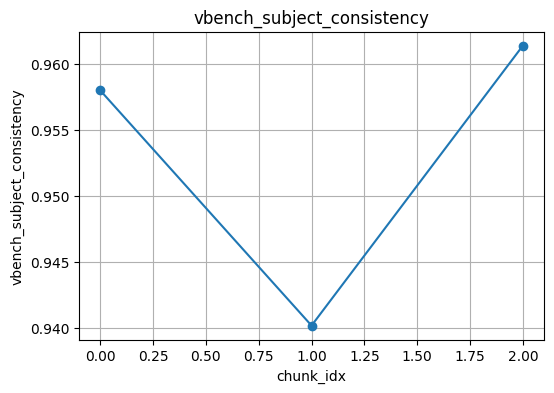

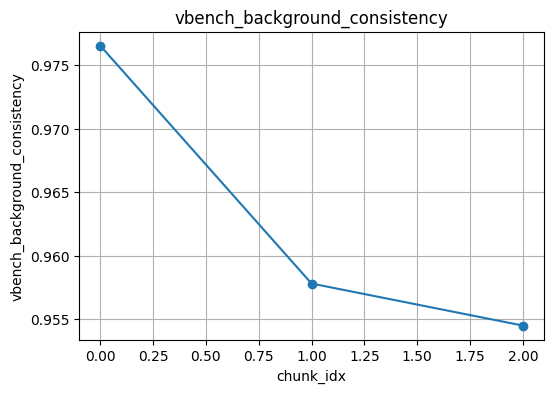

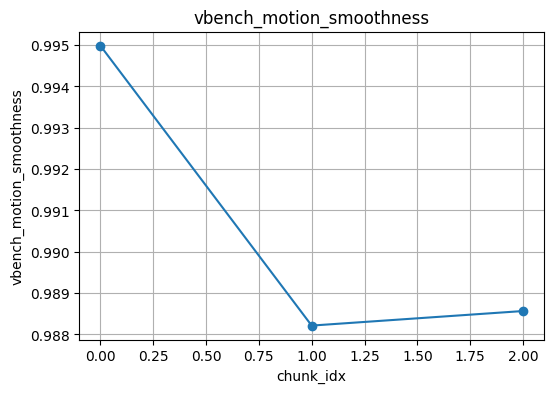

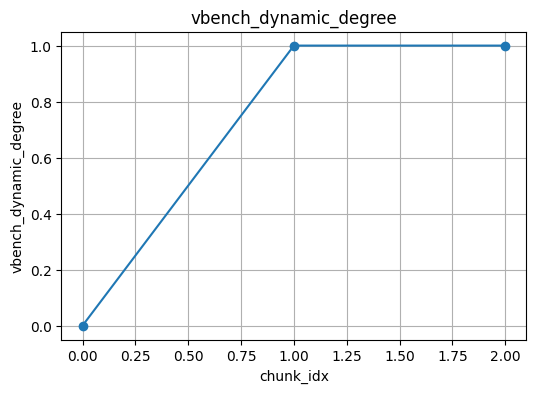

In [ ]:
# ===== Quick plots =====

import matplotlib.pyplot as plt

plot_cols = [
    "vbench_subject_consistency",
    "vbench_background_consistency",
    "vbench_motion_smoothness",
    "vbench_dynamic_degree",
]

chunk_df = pd.read_csv(chunk_csv)

for col in plot_cols:
    if col in chunk_df.columns:
        plt.figure(figsize=(6, 4))
        plt.plot(chunk_df["chunk_idx"], chunk_df[col], marker="o")
        plt.title(col)
        plt.xlabel("chunk_idx")
        plt.ylabel(col)
        plt.grid(True)
        plt.show()

## Генерация по сабсету из UCF101

In [ ]:
""" в сэмпел 144 видео 48 классов по 3 видео в каждом, чтобы не ждать слишком долго
возьмем тоько 3 класса - 9 видео """

samples_df = pd.read_csv(
    "/content/drive/MyDrive/datasets/UCF101_subset/_prepared/samples.csv")

chosen_classes = ["ApplyEyeMakeup", "BenchPress", "Typing"]

samples_3x3_df = (
    samples_df[samples_df["class"].isin(chosen_classes)]
    .groupby("class", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

samples_3x3_csv = "/content/drive/MyDrive/datasets/UCF101_subset/_prepared/samples_3x3.csv"
samples_3x3_df.to_csv(samples_3x3_csv, index=False)

DATASET_ROOT = Path("/content/drive/MyDrive/datasets/UCF101_subset")
GENERATED_ROOT = DATASET_ROOT / "_generated" / "wan_i2v_ucf101_v1" / "debug_3x3"

generated_manifest_path, failed_manifest_path = generate_from_csv(
    csv_path="/content/drive/MyDrive/datasets/UCF101_subset/_prepared/samples_3x3.csv",
    generated_root=str(GENERATED_ROOT),
    width=320,
    height=512,
    steps=4,
    cfg_scale=1.0,
    sampler_name="euler",
    scheduler="simple",
    frames=40,
    fps=8,
    output_format="mp4",
    same_seed=False,
    negative_prompt_value="",
)

[1/9] generating ApplyEyeMakeup | v_ApplyEyeMakeup_g01_c01
Using seed: 1351555744
Loading text encoder...


Loading input image...
Loading CLIP Vision for i2v conditioning...
Loading VAE...
Loading UNet...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)


/content/ComfyUI/custom_nodes/ComfyUI_GGUF/loader.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  torch_tensor = torch.from_numpy(tensor.data) # mmap


Generating video...
Attempting to release mmap (211)


  0%|          | 0/4 [00:00<?, ?it/s]

...

[9/9] generating Typing | v_Typing_g01_c03
Using seed: 4084106536
Loading text encoder...


Loading input image...
Loading CLIP Vision for i2v conditioning...
Loading VAE...
Loading UNet...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (163)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...
Last frame saved to: /content/ComfyUI/input/tmp_v_Typing_g01_c03_lastframe.png



Done.
generated: 9
failed: 0
manifest: /content/drive/MyDrive/datasets/UCF101_subset/_generated/wan_i2v_ucf101_v1/debug_3x3/generated_manifest.csv


In [ ]:
DATASET_ROOT = Path("/content/drive/MyDrive/datasets/UCF101_subset")
DEBUG_CSV = DATASET_ROOT / "_prepared" / "samples_debug.csv"
GENERATED_ROOT = DATASET_ROOT / "_generated" / "wan_i2v_ucf101_v1" / "debug"

generated_manifest_path, failed_manifest_path = generate_from_csv(
    csv_path=str(DEBUG_CSV),
    generated_root=str(GENERATED_ROOT),
    width=320,
    height=512,
    steps=4,
    cfg_scale=1.0,
    sampler_name="euler",
    scheduler="simple",
    frames=40,
    fps=8,
    output_format="mp4",
    same_seed=False,
    negative_prompt_value="",   # сюда потом можешь подставить свой negative prompt
)

## Генерация одного видео бейзлайн

In [ ]:
# @param {"type":"string"}
positive_prompt = "anime girl is dancing disco with big red cat"
# @param {"type":"string"}
negative_prompt = "plastic skin, shinny skin, white skin, unnatural skin, skin smoothness, smooth skinwithout testicles, good skin, unnatural skin, shinny skin, skin pores, skin plastic, smooth skins, bad anatomy, morbid anatomy, worst quality, low quality, normal quality, low res, blurry, grainy, pixelated:1.4, deformed, distorted, disfigured, mutation, mutated, bad anatomy, wrong anatomy, inaccurate anatomy, poorly drawn face, poorly drawn hands, missing fingers, extra fingers, fused fingers, extra limbs, missing limbs, cartoon, anime, illustration, 3d, cgi, sketch, painting, drawing, watermark, text, signature, logo, monochrome, b&w"
width = 320  # @param {"type":"number"}
height = 512  # @param {"type":"number"}
seed = 0  # @param {"type":"integer"}
steps = 4  # @param {"type":"integer"}
cfg_scale = 1.0  # @param {"type":"number"}
sampler_name = "euler"  # @param ["uni_pc", "euler", "dpmpp_2m", "ddim", "lms"]
scheduler = "simple"  # @param ["simple", "normal", "karras", "exponential"]
frames = 50  # @param {"type":"integer"}
fps = 8  # @param {"type":"integer"}
output_format = "mp4"  # @param ["mp4", "webm"]

output_path, last_frame_path = generate_video(
    image_path=None,
    positive_prompt=positive_prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    seed=seed,
    steps=steps,
    cfg_scale=cfg_scale,
    sampler_name=sampler_name,
    scheduler=scheduler,
    frames=frames,
    fps=fps,
    output_format=output_format,
    compute_similarity=False,   # сначала выключено
)

print("output_path:", output_path)
print("last_frame_path:", last_frame_path)
clear_memory()

Using seed: 1576529421
Please upload an image file:


# Считаем FVD

In [ ]:
clear_memory()
fvd_metric.init_feature_extractor()

result = fvd_metric.compute_fvd_from_manifest(
    manifest_csv=str(GENERATED_ROOT / "generated_manifest.csv"),
    num_frames=16,
    resize=(224, 224),
    max_videos=None,
)

print(result)
fvd_metric.unload_feature_extractor()


I3D initialized on cuda
{'fvd': 72.97346348175437, 'n_used': 9, 'n_failed': 0, 'bad_examples': []}
